# Function 7

<b> Description of the Sample Application:</b> You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance




## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |

## Progress log

| Week | Query point (x1–x6) | Output (y) | Method | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| 1 | 0.000000-0.000000-0.967840-0.233394-0.376268-0.804137 | 1.331930 | GP (RBF) + UCB (β=2.0), random-sample search | Exploration-heavy first query; landed on the domain edge for x1, x2 |
| 2 | *(computed below)* | *(pending — to be filled in after portal returns the result)* | GP (kernel chosen by CV) + UCB (β lowered) | Shift a step toward exploitation per Week-1 reflection |

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from plotting_utils import (
    plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
    plot_convergence, plot_parallel_coordinates
)


# Load and Analyse the Data

In [7]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.039632, 0.201121, 0.140302, 0.063997, 0.319477, 0.78773 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([1.3319298110135898]                                           , dtype = np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point))
Y_updated      = np.append(Y0, Y_w1_new_point)

#print(X_updated)
#print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

In [9]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)

Input  Shape: (31, 6)
Inputs:
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0

# Data Exploration

In [12]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  31.000000  31.000000  31.000000  31.000000  31.000000  31.000000   
mean    0.495651   0.389523   0.381567   0.498341   0.462435   0.494479   
std     0.310590   0.250783   0.311993   0.317138   0.310578   0.270351   
min     0.039632   0.011813   0.003635   0.063997   0.014944   0.051100   
25%     0.185615   0.198333   0.084639   0.218099   0.190980   0.298887   
50%     0.541241   0.377440   0.295542   0.449982   0.420428   0.585236   
75%     0.777431   0.538107   0.644549   0.820098   0.718908   0.720049   
max     0.942451   0.924694   0.924571   0.961017   0.998655   0.951014   

               Y  
count  31.000000  
mean    0.255488  
std     0.362207  
min     0.002701  
25%     0.018039  
50%     0.083747  
75%     0.375144  
max     1.364968  


In [14]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
Y      0
dtype: int64


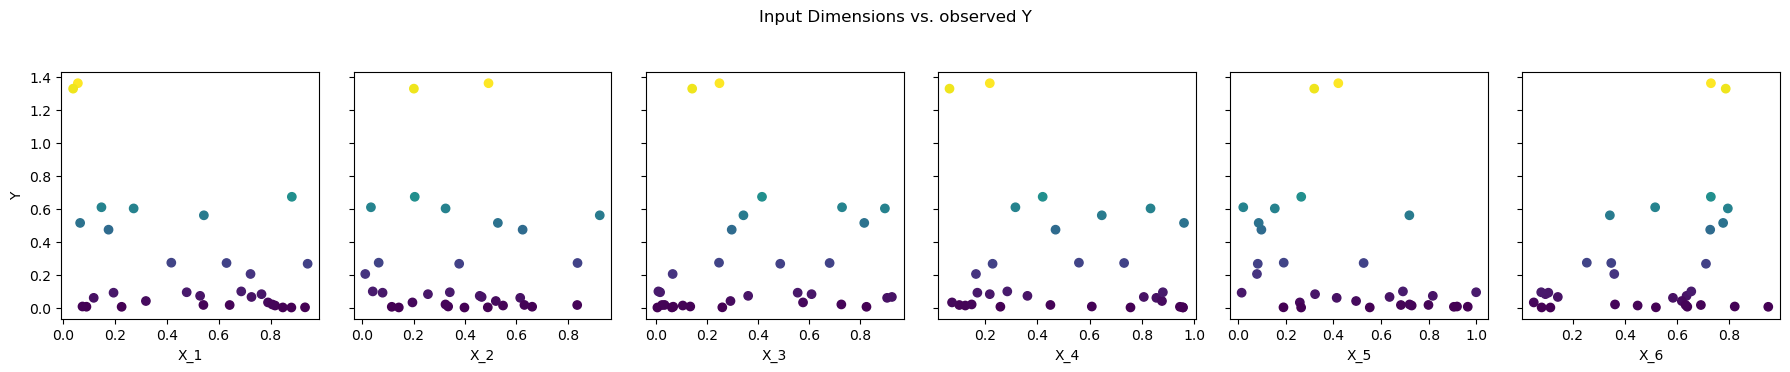

In [16]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

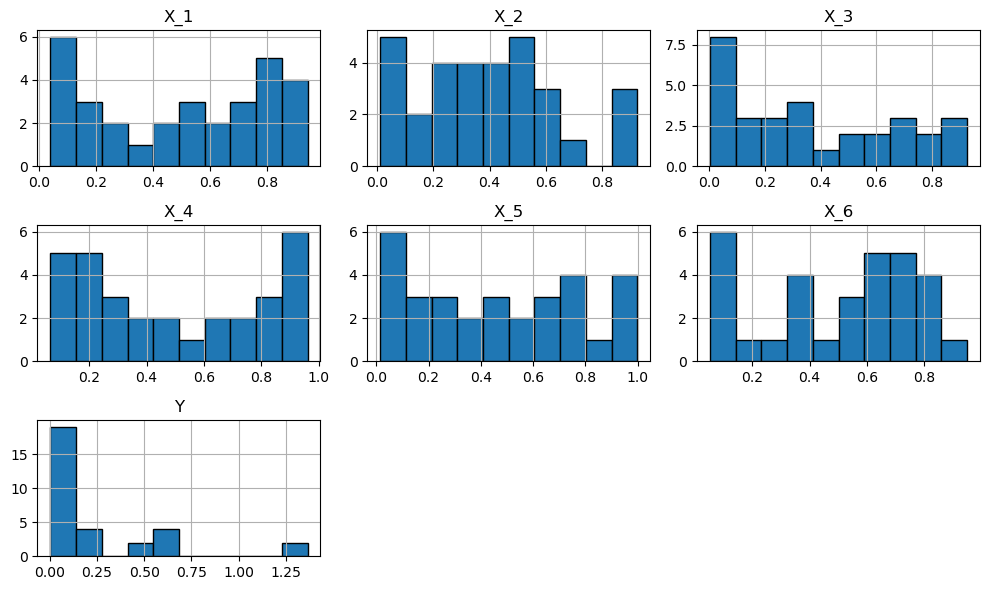

In [18]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [20]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.4257569228391833
 corr(X_2, Y) = -0.03710187128436065
 corr(X_3, Y) = 0.0672083951270977
 corr(X_4, Y) = -0.20149568799904768
 corr(X_5, Y) = -0.3612125739925048
 corr(X_6, Y) = 0.36208185502990226


<Axes: >

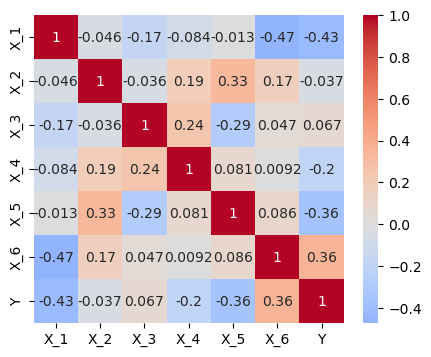

In [22]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

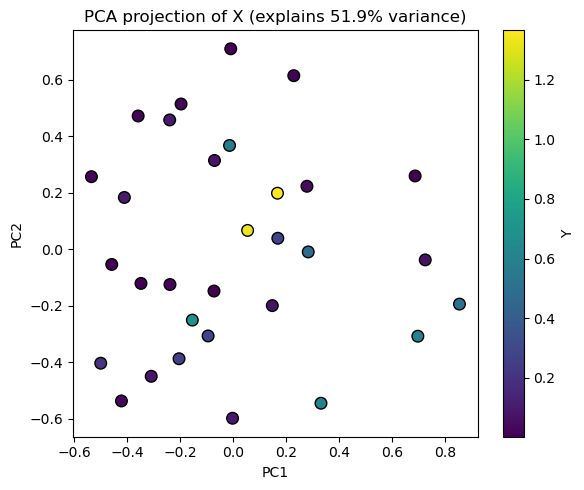

In [24]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "Y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum() * 100:.1f}% variance)")
plt.tight_layout()

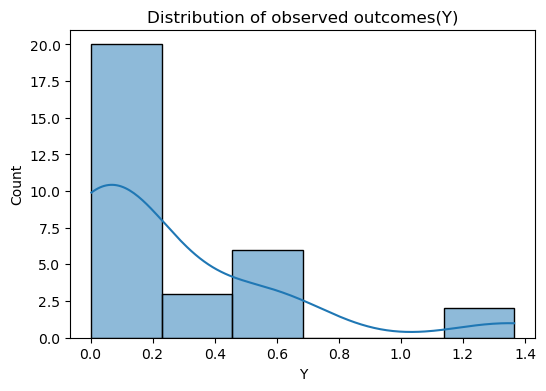

In [26]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [63]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(6), length_scale_bounds = (1e-2, 1e1)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [66]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.375**2 * RBF(length_scale=[1.03, 0.702, 10, 0.473, 0.218, 0.385]) + WhiteKernel(noise_level=0.00266)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [69]:
# Setting a higher beta(= 2.0) for Week -1
beta         = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (20000, 6))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.03963172 0.20112069 0.14030216 0.06399666 0.31947665 0.78773019]
UCB Score: 1.668385e+00


# Week 2: Kernel Comparison
RBF assumes an infinitely 
smooth surfac.; Matern is typically a better match for ML-performance landscape2). Both kernels are compared here with 5-fold cross-validated predicti e
log-likelihood t (31-pont) data et, and the better one selected.ook.

In [34]:
DIM   = 6
def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    return GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)

kernel_options = {  
    "RBF":            RBF(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1), nu = 2.5),
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls   = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std = True)
        sigma     = np.maximum(sigma, 1e-6)
        ll        = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key = cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 2: {best_kernel_name}")

  RBF             : CV log-likelihood = -20.765
  Matern(nu = 2.5): CV log-likelihood = -11.763

Selected kernel for Week 2: Matern(nu = 2.5)


# Week2: Bayesian Optimisation Function

In [44]:
def bayesian_optimization_step(X, Y, kernel, beta = 2.0, n_candidates = 20000, n_restarts = 40, use_optimizer = True, seed = 7):
    
    rng    = np.random.default_rng(seed)
    n_dims = X.shape[1]
    bounds = [(0.0, 1.0)] * n_dims

    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer=8, random_state = 0)
    gp.fit(X, Y)

    def ucb(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return mu + beta * sigma

    # Evaluate a random candidate set
    candidates       = rng.uniform(0, 1, size = (n_candidates, n_dims))
    candidate_ucb    = ucb(candidates)
    best_idx         = np.argmax(candidate_ucb)
    next_x, next_ucb = candidates[best_idx], candidate_ucb[best_idx]

    if use_optimizer:
        starts   = rng.uniform(0, 1, size = (n_restarts, n_dims))
        best_val = -next_ucb
        for x0 in starts:
            res  = minimize(lambda x: -ucb(x)[0], x0, method = "L-BFGS-B", bounds = bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, 0.0, 1.0)
        next_ucb = ucb(next_x)[0]

    return {
        "gp": gp, "next_x": next_x, "next_ucb": next_ucb,
        "candidates": candidates, "candidate_ucb": candidate_ucb,
    }


In [46]:
# Week 2: Calling the Bayesian Optimisation Function
beta   = 1.2       # In week 2, beta is lowered from 2.0 to 1.2

result = bayesian_optimization_step(X, Y, chosen_kernel, beta = beta, n_candidates = 20000, n_restarts = 40, seed = 7)
gp = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"Kernel used   : {best_kernel_name}")
print(f"β             : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")


Kernel used   : Matern(nu = 2.5)
β             : 1.2
Next point    : [0.       0.       1.       0.198783 0.377305 0.792654]
Predicted mean: 1.3974   std: 0.1044   UCB: 1.5227


# Perform Visualisation

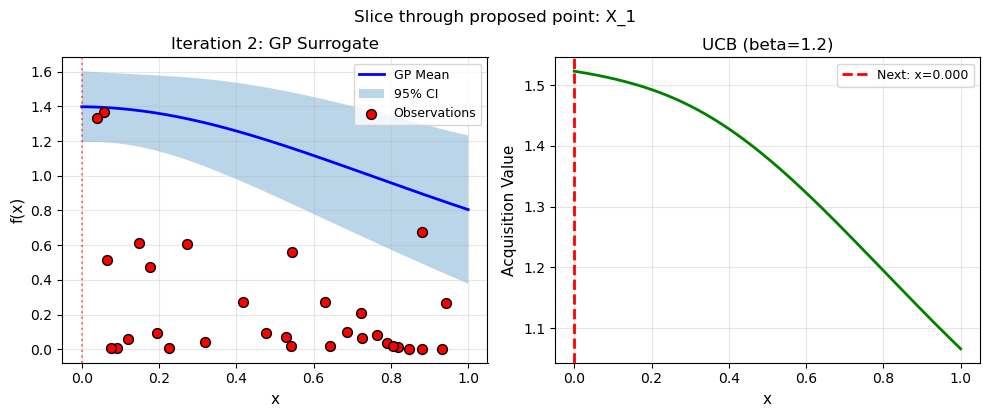

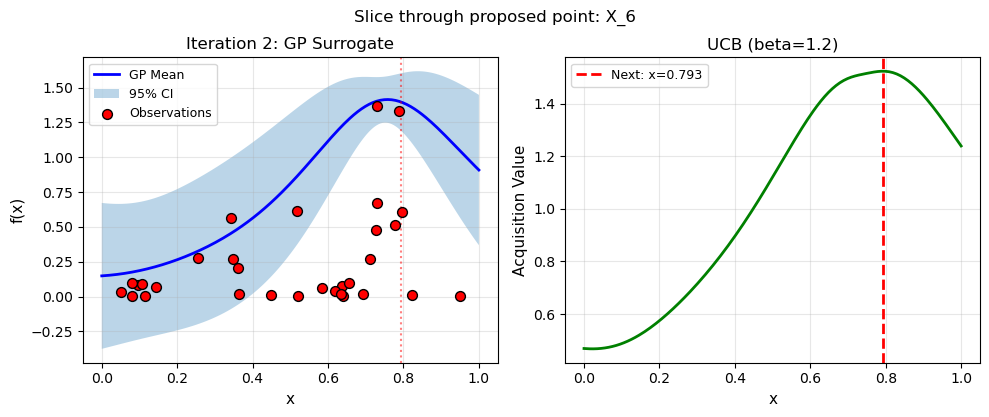

In [58]:
corrs    = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]
grid     = np.linspace(0, 1, 200).reshape(-1, 1)

for d in top_dims:
    Xg            = np.tile(next_x, (len(grid), 1))
    Xg[:, d]      = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std = True)
    ucb_g         = mu_g + beta * sigma_g

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train = Y,
        X_test=grid, mu = mu_g, sigma = sigma_g,
        acquisition_values = ucb_g, X_next  =next_x[d],
        iteration = 2, acq_name = f"UCB (beta={beta})"
    )
    fig.suptitle(f"Slice through proposed point: X_{d+1}", y = 1.03)
    plt.show()


# Convbergence and Top Solution

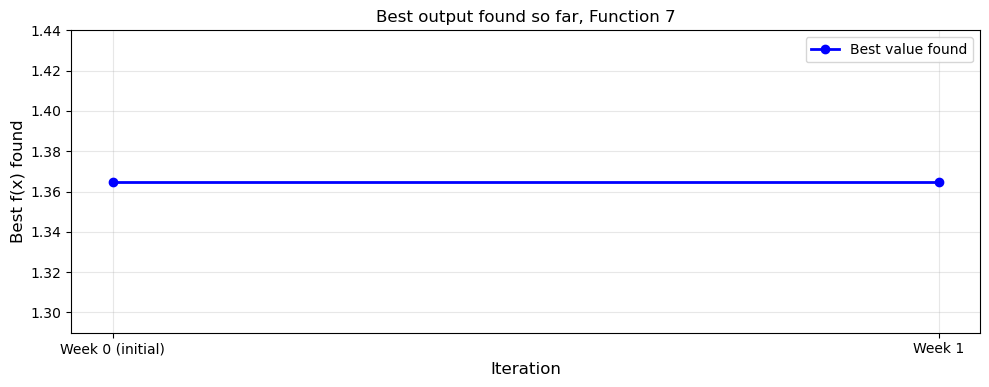

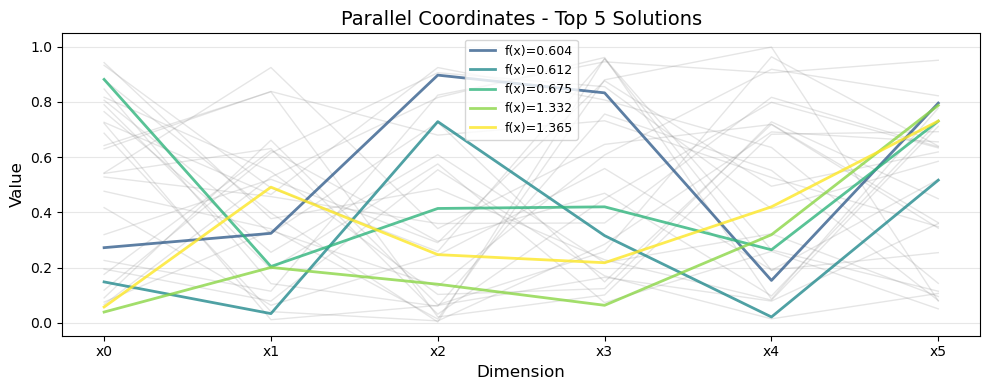

In [60]:
# Best-so-far after each stage of data collection
best_after_initial = Y[:-1].max()          # best among the original 30 points
best_after_week1   = Y.max()               # best after appending the Week-1 point
best_values        = [best_after_initial, best_after_week1]

plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0 (initial)", "Week 1"])
plt.title("Best output found so far, Function 7")
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


# Portal Submission 

In [50]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.000000-0.000000-1.000000-0.198783-0.377305-0.792654
